## Natural Gas Pipeline Pressure Drop Analysis Using Python
### A Computational Study of Series-Parallel Gas Pipeline Networks

##### Part 1: Setup and Unit Conversions

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Base constants
BASE_PRESSURE_PSIA = 14.7
BASE_TEMPERATURE_F = 60.0
BASE_TEMPERATURE_R = BASE_TEMPERATURE_F + 460.0

# Weymouth constant for q in SCFH (standard cubic feet per hour)
WEYMOUTH_CONSTANT_SCFH = 18.062

In [3]:
# define unit conversion functions (for flow rates and gas temperature)

def flow_to_scfh(flow_value, flow_unit):
    """
    Convert gas flow rate to SCFH.

    Parameters
    ----------
    flow_value : float
        Numerical value of the flow rate.
    flow_unit : str
        Unit of flow rate: 'SCFH', 'SCFD', or 'MMSCFD'.

    Returns
    -------
    float
        Flow rate in SCFH.
    """
    validate_positive(flow_value, "Flow rate")
    flow_unit = flow_unit.strip().upper()

    if flow_unit == "SCFH":
        return flow_value
    elif flow_unit == "SCFD":
        return flow_value / 24
    elif flow_unit == "MMSCFD":
        return flow_value * 1_000_000 / 24
    else:
        raise ValueError("Unsupported flow unit. Use 'SCFH', 'SCFD', or 'MMSCFD'.")


def flow_to_scfd(flow_value, flow_unit):
    """
    Convert gas flow rate to SCFD.

    Parameters
    ----------
    flow_value : float
        Numerical value of the flow rate.
    flow_unit : str
        Unit of flow rate: 'SCFH', 'SCFD', or 'MMSCFD'.

    Returns
    -------
    float
        Flow rate in SCFD.
    """
    validate_positive(flow_value, "Flow rate")
    flow_unit = flow_unit.strip().upper()

    if flow_unit == "SCFH":
        return flow_value * 24
    elif flow_unit == "SCFD":
        return flow_value
    elif flow_unit == "MMSCFD":
        return flow_value * 1_000_000
    else:
        raise ValueError("Unsupported flow unit. Use 'SCFH', 'SCFD', or 'MMSCFD'.")


def fahrenheit_to_rankine(temp_f):
    """
    Convert temperature from degree Fahrenheit to Rankine.

    Parameters
    ----------
    temp_f : float
        Temperature in degree Fahrenheit.

    Returns
    -------
    float
        Temperature in Rankine.
    """
    return temp_f + 460.0

In [4]:
# validation function
def validate_positive(value, name):
    """
    Ensure a parameter is positive.
    
    Parameters
    ----------
    value : float
        Value to validate.
    name : str
        Name of the parameter.
    """
    if value <= 0:
        raise ValueError(f"{name} must be greater than zero. Got {value}.")

In [5]:
# test the conversion functions
flow_value = 50.0
flow_unit = "MMSCFD"
temp_f = 60.0

flow_scfh = flow_to_scfh(flow_value, flow_unit)
flow_scfd = flow_to_scfd(flow_value, flow_unit)
temp_r = fahrenheit_to_rankine(temp_f)

print(f"Flow rate: {flow_value:.2f} {flow_unit}")
print(f"Flow rate in SCFH: {flow_scfh:,.2f} SCFH")
print(f"Flow rate in SCFD: {flow_scfd:,.2f} SCFD")
print(f"Temperature: {temp_f:.2f} °F = {temp_r:.2f} °R")

Flow rate: 50.00 MMSCFD
Flow rate in SCFH: 2,083,333.33 SCFH
Flow rate in SCFD: 50,000,000.00 SCFD
Temperature: 60.00 °F = 520.00 °R


In [6]:
validate_positive(50.0, "Flow rate")
validate_positive(14.0, "Diameter")
validate_positive(20.0, "Length")

print("Basic validation checks passed.")

Basic validation checks passed.


###### The Weymouth equation used in this project is shown below

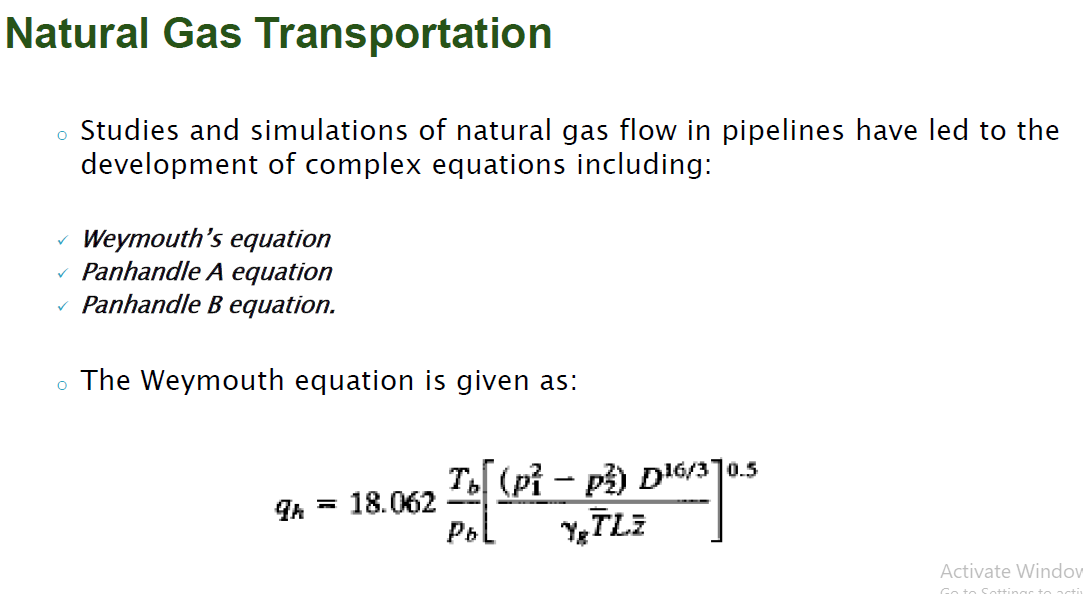

In [7]:
# Weymouth equation:
#
# q_h = 18.062 * (Tb / Pb) * [ ((P1^2 - P2^2) * D^(16/3)) / (G * T * L * Z) ]^0.5
#
# Rearranging:
#
# P1^2 - P2^2 = (q_h^2 * G * T * L * Z) / ((18.062)^2 * (Tb/Pb)^2 * D^(16/3))
#
# Therefore:
#
# P2 = sqrt(P1^2 - term)
# delta_P = P1 - P2
#
# where:
# q_h = flow rate in SCFH
# P1, P2 = pressure in psia
# D = diameter in inches
# L = length in miles
# G = gas specific gravity
# T = flowing temperature in Rankine
# Z = compressibility factor

##### Part 2: Weymouth Equation Implementation

In [8]:
# define function for the outlet pressure
def weymouth_outlet_pressure(
    flow_value,
    P1,
    D,
    L,
    G,
    T_f,
    Z,
    flow_unit="MMSCFD",
    Tb_f=60.0,
    Pb=14.7
):
    """
    Calculate outlet pressure P2 using the lecturer's Weymouth equation.

    Parameters
    ----------
    flow_value : float
        Gas flow rate value.
    P1 : float
        Inlet pressure in psia.
    D : float
        Pipe diameter in inches.
    L : float
        Pipe length in miles.
    G : float
        Gas specific gravity (dimensionless).
    T_f : float
        Flowing gas temperature in degree Fahrenheit.
    Z : float
        Compressibility factor (dimensionless).
    flow_unit : str, optional
        Flow-rate unit: 'SCFH', 'SCFD', or 'MMSCFD'. Default is 'MMSCFD'.
    Tb_f : float, optional
        Base temperature in degree Fahrenheit. Default is 60°F.
    Pb : float, optional
        Base pressure in psia. Default is 14.7 psia.

    Returns
    -------
    float
        Outlet pressure P2 in psia.
    """
    validate_positive(P1, "Inlet pressure P1")
    validate_positive(D, "Diameter D")
    validate_positive(L, "Length L")
    validate_positive(G, "Gas specific gravity G")
    validate_positive(Z, "Compressibility factor Z")
    validate_positive(Pb, "Base pressure Pb")

    # Convert flow to SCFH for Weymouth equation
    q_h = flow_to_scfh(flow_value, flow_unit)

    # Convert temperatures to Rankine
    T = fahrenheit_to_rankine(T_f)
    Tb = fahrenheit_to_rankine(Tb_f)

    # Denominator term from rearranged equation
    denominator = (WEYMOUTH_CONSTANT_SCFH ** 2) * ((Tb / Pb) ** 2) * (D ** (16 / 3))

    # Pressure-squared drop term
    delta_p_squared_term = (q_h ** 2 * G * T * L * Z) / denominator

    # Solve for P2^2
    P2_squared = P1 ** 2 - delta_p_squared_term

    if P2_squared <= 0:
        raise ValueError(
            "Calculated P2^2 is zero or negative. "
            "This suggests the selected flow rate is too high for the given pipeline conditions."
        )

    # Outlet pressure
    P2 = np.sqrt(P2_squared)
    return P2

In [9]:
# define a function for the pressure drop
def weymouth_pressure_drop(
    flow_value,
    P1,
    D,
    L,
    G,
    T_f,
    Z,
    flow_unit="MMSCFD",
    Tb_f=60.0,
    Pb=14.7
):
    """
    Calculate outlet pressure and pressure drop using the lecturer's Weymouth equation.

    Returns
    -------
    tuple
        P2 : outlet pressure in psia
        delta_P : pressure drop in psi
    """
    P2 = weymouth_outlet_pressure(
        flow_value=flow_value,
        P1=P1,
        D=D,
        L=L,
        G=G,
        T_f=T_f,
        Z=Z,
        flow_unit=flow_unit,
        Tb_f=Tb_f,
        Pb=Pb
    )

    delta_P = P1 - P2
    return P2, delta_P

##### Example: Single Pipeline Test Case

In [10]:
# Sample test case
flow_test = 50.0
flow_unit_test = "MMSCFD"

P1_test = 1000.0   # psia
D_test = 12.0      # inches
L_test = 20.0      # miles
G_test = 0.60
T_f_test = 60.0    # °F
Z_test = 0.90

P2_test, dP_test = weymouth_pressure_drop(
    flow_value=flow_test,
    P1=P1_test,
    D=D_test,
    L=L_test,
    G=G_test,
    T_f=T_f_test,
    Z=Z_test,
    flow_unit=flow_unit_test
)

print(f"Flow rate = {flow_test:.2f} {flow_unit_test}")
print(f"Inlet pressure, P1 = {P1_test:.2f} psia")
print(f"Outlet pressure, P2 = {P2_test:.6f} psia")
print(f"Pressure drop, ΔP = {dP_test:.6f} psi")

Flow rate = 50.00 MMSCFD
Inlet pressure, P1 = 1000.00 psia
Outlet pressure, P2 = 946.144185 psia
Pressure drop, ΔP = 53.855815 psi


In [11]:
# Print result in a DataFrame table
weymouth_result_df = pd.DataFrame({
    "Parameter": [
        "Flow rate",
        "Flow-rate unit",
        "Inlet pressure",
        "Outlet pressure",
        "Pressure drop",
        "Diameter",
        "Length",
        "Gas specific gravity",
        "Temperature",
        "Compressibility factor"
    ],
    "Value": [
        flow_test,
        flow_unit_test,
        P1_test,
        P2_test,
        dP_test,
        D_test,
        L_test,
        G_test,
        T_f_test,
        Z_test
    ],
    "Unit": [
        "-",
        "-",
        "psia",
        "psia",
        "psi",
        "inches",
        "miles",
        "-",
        "°F",
        "-"
    ]
})

weymouth_result_df

,Parameter,Value,Unit
0,Flow rate,50.0,-
1,Flow-rate unit,MMSCFD,-
2,Inlet pressure,1000.0,psia
3,Outlet pressure,946.144185,psia
4,Pressure drop,53.855815,psi
5,Diameter,12.0,inches
6,Length,20.0,miles
7,Gas specific gravity,0.6,-
8,Temperature,60.0,°F
9,Compressibility factor,0.9,-


In [12]:
# Optional unit-flexibility check

P2_scfd, dP_scfd = weymouth_pressure_drop(
    flow_value=50_000_000,
    P1=1000.0,
    D=12.0,
    L=20.0,
    G=0.60,
    T_f=60.0,
    Z=0.90,
    flow_unit="SCFD"
)

P2_scfh, dP_scfh = weymouth_pressure_drop(
    flow_value=50_000_000 / 24,
    P1=1000.0,
    D=12.0,
    L=20.0,
    G=0.60,
    T_f=60.0,
    Z=0.90,
    flow_unit="SCFH"
)

print(f"P2 using MMSCFD input = {P2_test:.6f} psia")
print(f"P2 using SCFD input   = {P2_scfd:.6f} psia")
print(f"P2 using SCFH input   = {P2_scfh:.6f} psia")

P2 using MMSCFD input = 946.144185 psia
P2 using SCFD input   = 946.144185 psia
P2 using SCFH input   = 946.144185 psia


##### Part 3: Sensitivity Analysis with Weymouth.

This section investigates the influence of key pipeline parameters on outlet pressure and pressure drop using the Weymouth equation. One variable is varied at a time while the others are held constant.

In [13]:
# Define a base case for sensitivity analysis
base_case = {
    "flow_value": 50.0,      # MMSCFD
    "flow_unit": "MMSCFD",
    "P1": 1000.0,            # psia
    "D": 12.0,               # inches
    "L": 20.0,               # miles
    "G": 0.60,
    "T_f": 60.0,             # °F
    "Z": 0.90
}

base_case

{'flow_value': 50.0,
 'flow_unit': 'MMSCFD',
 'P1': 1000.0,
 'D': 12.0,
 'L': 20.0,
 'G': 0.6,
 'T_f': 60.0,
 'Z': 0.9}

In [14]:
# Sensitivity to flow rate
flow_rates = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])

flow_results = []

for q in flow_rates:
    P2, dP = weymouth_pressure_drop(
        flow_value=q,
        P1=base_case["P1"],
        D=base_case["D"],
        L=base_case["L"],
        G=base_case["G"],
        T_f=base_case["T_f"],
        Z=base_case["Z"],
        flow_unit="MMSCFD"
    )
    
    flow_results.append({
        "Flow Rate (MMSCFD)": q,
        "Outlet Pressure, P2 (psia)": P2,
        "Pressure Drop, ΔP (psi)": dP
    })

flow_df = pd.DataFrame(flow_results)
flow_df

,Flow Rate (MMSCFD),"Outlet Pressure, P2 (psia)","Pressure Drop, ΔP (psi)"
0,10,997.901575,2.098425
1,20,991.579654,8.420346
2,30,980.952585,19.047415
3,40,965.878276,34.121724
4,50,946.144185,53.855815
5,60,921.450974,78.549026
6,70,891.386607,108.613393
7,80,855.384928,144.615072
8,90,812.657228,187.342772
9,100,762.073010,237.926990


##### Diagnostic plots:

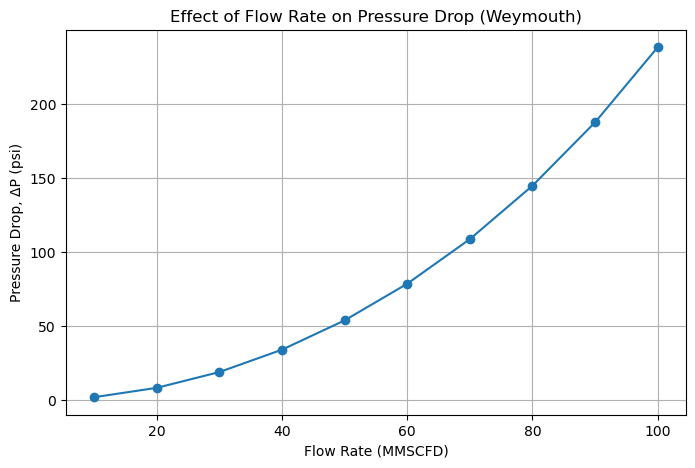

In [15]:
# Plot effect of flow rate on pressure drop
plt.figure(figsize=(8, 5))
plt.plot(flow_df["Flow Rate (MMSCFD)"], flow_df["Pressure Drop, ΔP (psi)"], marker='o')
plt.xlabel("Flow Rate (MMSCFD)")
plt.ylabel("Pressure Drop, ΔP (psi)")
plt.title("Effect of Flow Rate on Pressure Drop (Weymouth)")
plt.grid(True)
plt.show()

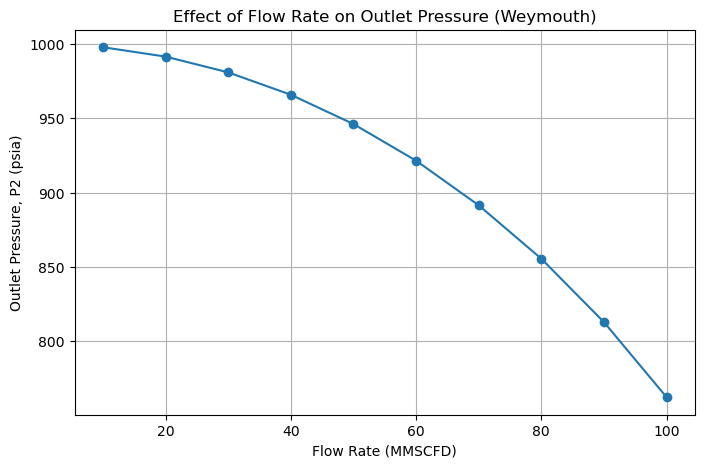

In [16]:
# Plot effect of flow rate on Outlet Pressur
plt.figure(figsize=(8, 5))
plt.plot(flow_df["Flow Rate (MMSCFD)"], flow_df["Outlet Pressure, P2 (psia)"], marker='o')
plt.xlabel("Flow Rate (MMSCFD)")
plt.ylabel("Outlet Pressure, P2 (psia)")
plt.title("Effect of Flow Rate on Outlet Pressure (Weymouth)")
plt.grid(True)
plt.show()

**Engineering interpretation:**  
As gas flow rate increases, the outlet pressure decreases while the pressure drop increases. This is expected because higher gas throughput leads to greater frictional losses along the pipeline.

In [17]:
# Sensitivity to pipeline diameter
diameters = np.array([6, 8, 10, 12, 14, 16, 18, 20])

diameter_results = []

for d in diameters:
    try:
        P2, dP = weymouth_pressure_drop(
            flow_value=base_case["flow_value"],
            P1=base_case["P1"],
            D=d,
            L=base_case["L"],
            G=base_case["G"],
            T_f=base_case["T_f"],
            Z=base_case["Z"],
            flow_unit=base_case["flow_unit"]
        )

        diameter_results.append({
            "Diameter (inches)": d,
            "Outlet Pressure, P2 (psia)": P2,
            "Pressure Drop, ΔP (psi)": dP
        })

    except ValueError as e:
        diameter_results.append({
            "Diameter (inches)": d,
            "Outlet Pressure, P2 (psia)": np.nan,
            "Pressure Drop, ΔP (psi)": np.nan
        })
        print(f"Skipping diameter {d} in: {e}")

diameter_df = pd.DataFrame(diameter_results)
diameter_df

Skipping diameter 6 in: Calculated P2^2 is zero or negative. This suggests the selected flow rate is too high for the given pipeline conditions.


,Diameter (inches),"Outlet Pressure, P2 (psia)","Pressure Drop, ΔP (psi)"
0,6,NaN,NaN
1,8,298.178784,701.821216
2,10,850.208592,149.791408
3,12,946.144185,53.855815
4,14,976.696667,23.303333
5,16,988.636496,11.363504
6,18,993.953009,6.046991
7,20,996.557035,3.442965


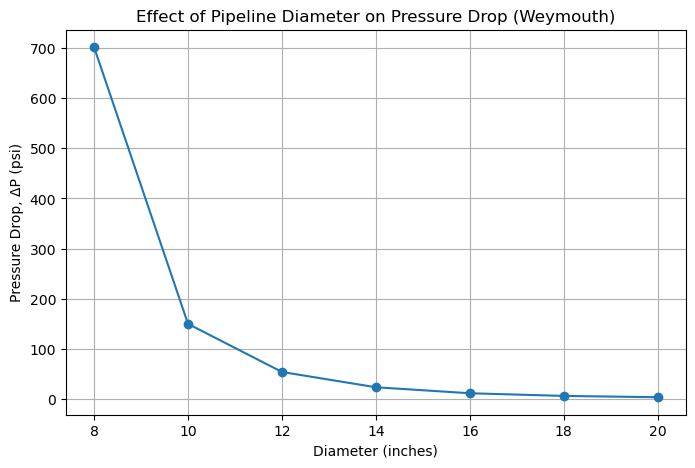

In [18]:
# Plot effect of diameter on Pressure Drop
plt.figure(figsize=(8, 5))
plt.plot(diameter_df["Diameter (inches)"], diameter_df["Pressure Drop, ΔP (psi)"], marker='o')
plt.xlabel("Diameter (inches)")
plt.ylabel("Pressure Drop, ΔP (psi)")
plt.title("Effect of Pipeline Diameter on Pressure Drop (Weymouth)")
plt.grid(True)
plt.show()

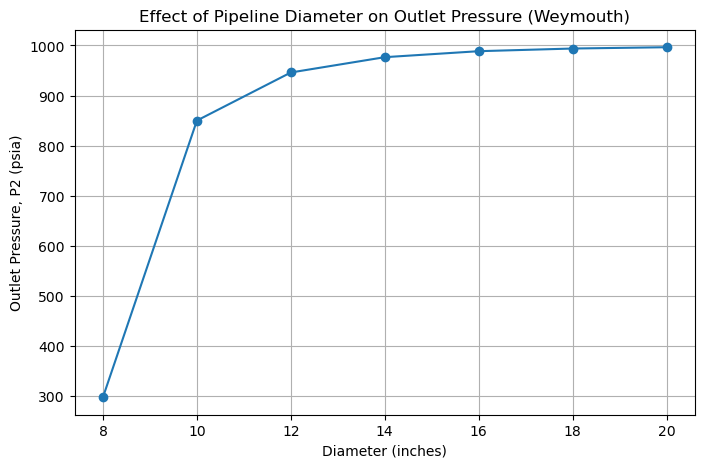

In [19]:
# Plot effect of diameter on outlet pressure
plt.figure(figsize=(8, 5))
plt.plot(diameter_df["Diameter (inches)"], diameter_df["Outlet Pressure, P2 (psia)"], marker='o')
plt.xlabel("Diameter (inches)")
plt.ylabel("Outlet Pressure, P2 (psia)")
plt.title("Effect of Pipeline Diameter on Outlet Pressure (Weymouth)")
plt.grid(True)
plt.show()

**Engineering interpretation:**  
As pipeline diameter increases, pressure drop decreases significantly and outlet pressure increases. Tests with smaller pipeline diameter values shows there is a minimum threshold pipeline diameter allowable for a given flow rate and inlet pressure. This implies that some pipeline sizes (diameter) may be hydraulically inadequate for the required gas throughput.

In [20]:
# Sensitivity to pipeline length
lengths = np.array([5, 10, 15, 20, 25, 30, 40, 50, 60])

length_results = []

for L in lengths:
    P2, dP = weymouth_pressure_drop(
        flow_value=base_case["flow_value"],
        P1=base_case["P1"],
        D=base_case["D"],
        L=L,
        G=base_case["G"],
        T_f=base_case["T_f"],
        Z=base_case["Z"],
        flow_unit=base_case["flow_unit"]
    )
    
    length_results.append({
        "Length (miles)": L,
        "Outlet Pressure, P2 (psia)": P2,
        "Pressure Drop, ΔP (psi)": dP
    })

length_df = pd.DataFrame(length_results)
length_df

,Length (miles),"Outlet Pressure, P2 (psia)","Pressure Drop, ΔP (psi)"
0,5,986.811636,13.188364
1,10,973.444610,26.555390
2,15,959.891459,40.108541
3,20,946.144185,53.855815
4,25,932.194198,67.805802
5,30,918.032258,81.967742
6,40,889.031853,110.968147
7,50,859.052993,140.947007
8,60,827.989405,172.010595


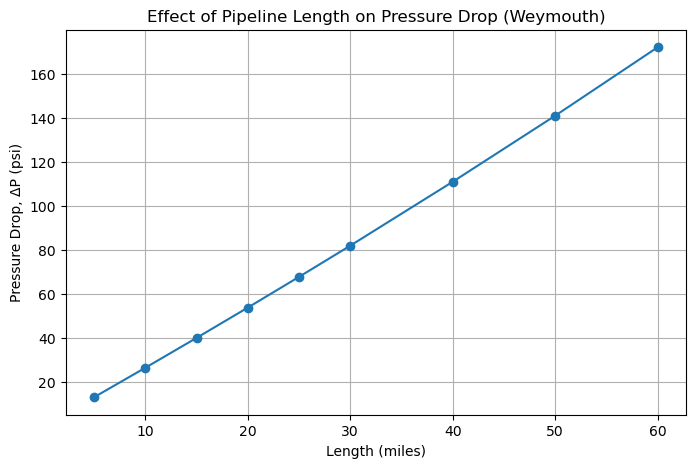

In [21]:
# Plot effect of length on pressure drop
plt.figure(figsize=(8, 5))
plt.plot(length_df["Length (miles)"], length_df["Pressure Drop, ΔP (psi)"], marker='o')
plt.xlabel("Length (miles)")
plt.ylabel("Pressure Drop, ΔP (psi)")
plt.title("Effect of Pipeline Length on Pressure Drop (Weymouth)")
plt.grid(True)
plt.show()

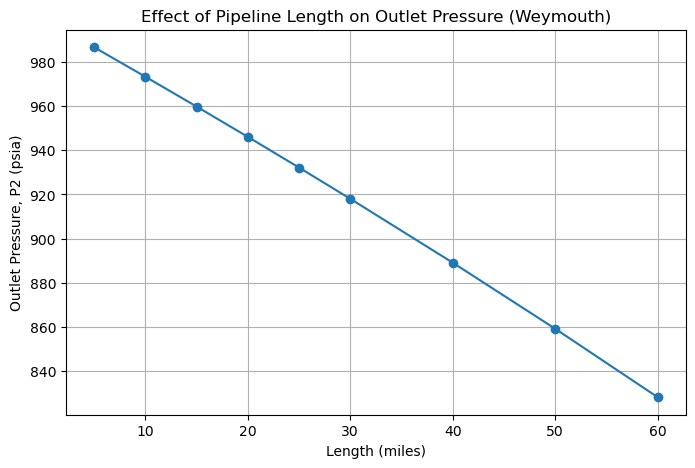

In [22]:
# Plot effect of length on outlet pressure
plt.figure(figsize=(8, 5))
plt.plot(length_df["Length (miles)"], length_df["Outlet Pressure, P2 (psia)"], marker='o')
plt.xlabel("Length (miles)")
plt.ylabel("Outlet Pressure, P2 (psia)")
plt.title("Effect of Pipeline Length on Outlet Pressure (Weymouth)")
plt.grid(True)
plt.show()

**Engineering interpretation:**  
As pipeline length increases, outlet pressure decreases and pressure drop increases. This occurs because a longer pipeline provides a greater flow path over which frictional losses accumulate.

In [23]:
# Summary table of trends
summary_trends_df = pd.DataFrame({
    "Parameter Varied": ["Flow Rate", "Diameter", "Length"],
    "Effect on Pressure Drop": ["Increases", "Decreases", "Increases"],
    "Effect on Outlet Pressure": ["Decreases", "Increases", "Decreases"]
})

summary_trends_df

,Parameter Varied,Effect on Pressure Drop,Effect on Outlet Pressure
0,Flow Rate,Increases,Decreases
1,Diameter,Decreases,Increases
2,Length,Increases,Decreases


#### Part 4 — Series and Parallel Pipeline Modeling

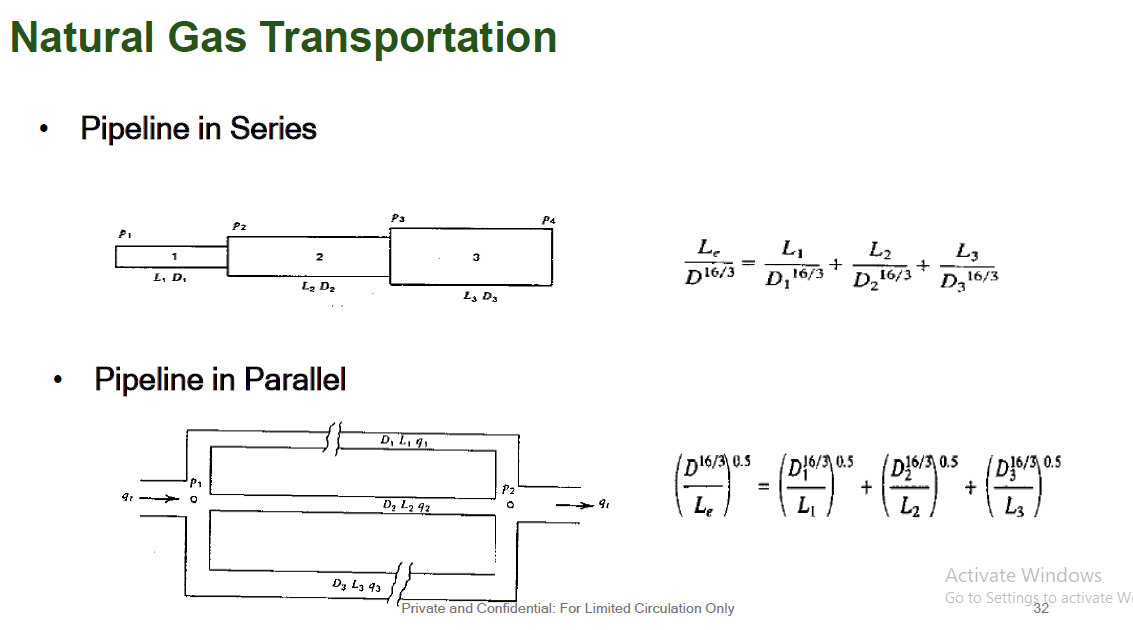

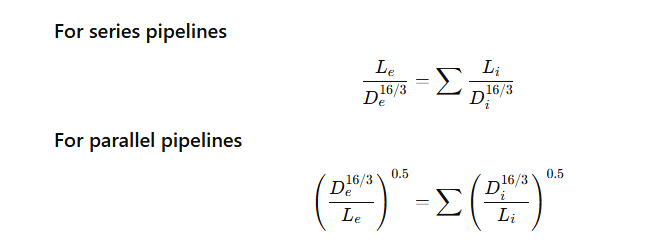

This section implements the equivalent pipeline relationships for series and parallel gas pipeline systems using the Weymouth-based formulations.

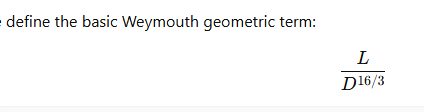

In [24]:
def pipe_resistance_term(L, D):
    """
    Compute the Weymouth resistance term for a single pipe.

    Parameters
    ----------
    L : float
        Pipe length in miles.
    D : float
        Pipe diameter in inches.

    Returns
    -------
    float
        Resistance term L / D^(16/3)
    """
    validate_positive(L, "Length L")
    validate_positive(D, "Diameter D")
    
    return L / (D ** (16 / 3))

In [25]:
# For series, resistance terms simply add.
def equivalent_series_resistance(lengths, diameters):
    """
    Compute the equivalent Weymouth resistance term for pipes in series.

    Parameters
    ----------
    lengths : list or array-like
        List of pipe lengths in miles.
    diameters : list or array-like
        List of pipe diameters in inches.

    Returns
    -------
    float
        Equivalent resistance term:
        sum(L_i / D_i^(16/3))
    """
    if len(lengths) != len(diameters):
        raise ValueError("Lengths and diameters must have the same number of elements.")
    
    total_resistance = 0.0
    
    for L, D in zip(lengths, diameters):
        total_resistance += pipe_resistance_term(L, D)
    
    return total_resistance

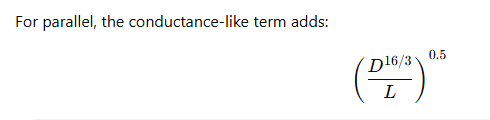

In [26]:
def equivalent_parallel_resistance(lengths, diameters):
    """
    Compute the equivalent Weymouth resistance term for pipes in parallel.

    Parameters
    ----------
    lengths : list or array-like
        List of pipe lengths in miles.
    diameters : list or array-like
        List of pipe diameters in inches.

    Returns
    -------
    float
        Equivalent resistance term in the form:
        L_e / D_e^(16/3)
    """
    if len(lengths) != len(diameters):
        raise ValueError("Lengths and diameters must have the same number of elements.")
    
    conductance_sum = 0.0
    
    for L, D in zip(lengths, diameters):
        validate_positive(L, "Length L")
        validate_positive(D, "Diameter D")
        conductance_sum += ((D ** (16 / 3)) / L) ** 0.5
    
    if conductance_sum <= 0:
        raise ValueError("Equivalent conductance sum must be positive.")
    
    equivalent_resistance = 1 / (conductance_sum ** 2)
    
    return equivalent_resistance

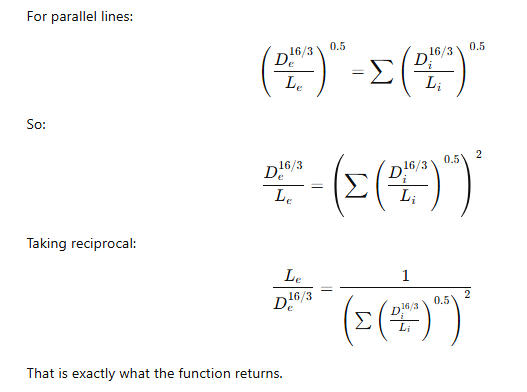

**Simple test for series**

In [27]:
# Test: series pipeline equivalent resistance
series_lengths = [10, 20, 15]
series_diameters = [8, 10, 12]

series_equiv = equivalent_series_resistance(series_lengths, series_diameters)

print(f"Equivalent series resistance term = {series_equiv:.8f}")

Equivalent series resistance term = 0.00027175


**Simple test for parallel**

In [28]:
# Test: parallel pipeline equivalent resistance
parallel_lengths = [20, 25]
parallel_diameters = [8, 10]

parallel_equiv = equivalent_parallel_resistance(parallel_lengths, parallel_diameters)

print(f"Equivalent parallel resistance term = {parallel_equiv:.8f}")

Equivalent parallel resistance term = 0.00004440


In [29]:
# putting the test results in a DataFrame
equivalent_terms_df = pd.DataFrame({
    "System Type": ["Series Example", "Parallel Example"],
    "Equivalent Resistance Term (L/D^(16/3))": [series_equiv, parallel_equiv]
})

equivalent_terms_df

,System Type,Equivalent Resistance Term (L/D^(16/3))
0,Series Example,0.000272
1,Parallel Example,0.000044


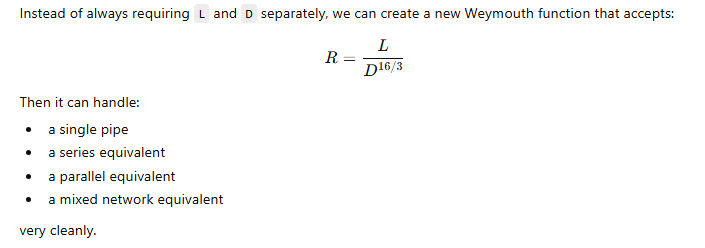

In [30]:
def weymouth_outlet_pressure_from_resistance(
    flow_value,
    P1,
    resistance_term,
    G,
    T_f,
    Z,
    flow_unit="MMSCFD",
    Tb_f=60.0,
    Pb=14.7
):
    """
    Calculate outlet pressure using the lecturer's Weymouth equation
    expressed in terms of the resistance term R = L / D^(16/3).

    Parameters
    ----------
    flow_value : float
        Gas flow rate value.
    P1 : float
        Inlet pressure in psia.
    resistance_term : float
        Equivalent resistance term L / D^(16/3).
    G : float
        Gas specific gravity.
    T_f : float
        Flowing gas temperature in °F.
    Z : float
        Compressibility factor.
    flow_unit : str, optional
        Flow-rate unit: 'SCFH', 'SCFD', or 'MMSCFD'.
    Tb_f : float, optional
        Base temperature in °F.
    Pb : float, optional
        Base pressure in psia.

    Returns
    -------
    float
        Outlet pressure in psia.
    """
    validate_positive(P1, "Inlet pressure P1")
    validate_positive(resistance_term, "Resistance term")
    validate_positive(G, "Gas specific gravity G")
    validate_positive(Z, "Compressibility factor Z")
    validate_positive(Pb, "Base pressure Pb")

    q_h = flow_to_scfh(flow_value, flow_unit)
    T = fahrenheit_to_rankine(T_f)
    Tb = fahrenheit_to_rankine(Tb_f)

    denominator = (WEYMOUTH_CONSTANT_SCFH ** 2) * ((Tb / Pb) ** 2)

    delta_p_squared_term = (q_h ** 2 * G * T * Z * resistance_term) / denominator

    P2_squared = P1 ** 2 - delta_p_squared_term

    if P2_squared <= 0:
        raise ValueError(
            "Calculated P2^2 is zero or negative. "
            "The selected flow may be too high for the given equivalent pipeline system."
        )

    return np.sqrt(P2_squared)

**Test Weymouth from resistance term on a single pipe**

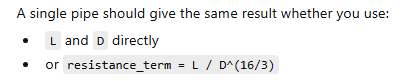

In [31]:
# Test consistency with a single pipe
single_R = pipe_resistance_term(L=20.0, D=12.0)

P2_direct, dP_direct = weymouth_pressure_drop(
    flow_value=50.0,
    P1=1000.0,
    D=12.0,
    L=20.0,
    G=0.60,
    T_f=60.0,
    Z=0.90,
    flow_unit="MMSCFD"
)

P2_from_R = weymouth_outlet_pressure_from_resistance(
    flow_value=50.0,
    P1=1000.0,
    resistance_term=single_R,
    G=0.60,
    T_f=60.0,
    Z=0.90,
    flow_unit="MMSCFD"
)

print(f"P2 from direct L and D     = {P2_direct:.6f} psia")
print(f"P2 from resistance term    = {P2_from_R:.6f} psia")

P2 from direct L and D     = 946.144185 psia
P2 from resistance term    = 946.144185 psia


#### Part 5: Case Study — Series-Parallel Natural Gas Pipeline Network

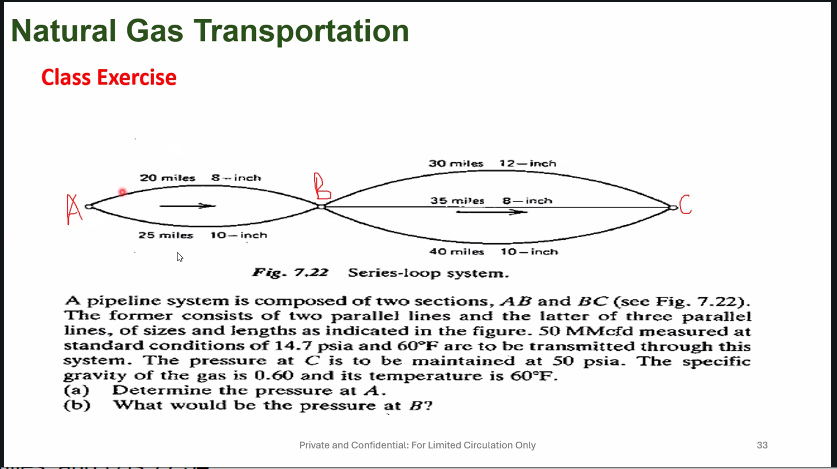

The system consists of two parallel lines between A and B, and three parallel lines between B and C. The parallel groups are first reduced to equivalent pipeline resistance terms, after which the full A–C system is treated as a series combination.

**Approach:** Resolve AB and then the BC parallel pipeline sections separately. Then treat the equivalent AB and BC in series to get A to C

This section presents a computational solution of a mixed series-parallel natural gas pipeline network using the Weymouth equation.

The analysis integrates:
- flow distribution in parallel pipelines,
- equivalent resistance modeling,
- pressure-squared formulation,
- and node pressure evaluation.

The workflow ensures consistency between system-level behavior and branch-level flow distribution.

In [32]:
# Problem data for the network

# Section AB: two parallel lines
AB_lengths = [20.0, 25.0]          # miles
AB_diameters = [8.0, 10.0]         # inches
AB_branch_labels = ["20-mile, 8-in line", "25-mile, 10-in line"]

# Section BC: three parallel lines
BC_lengths = [30.0, 35.0, 40.0]    # miles
BC_diameters = [12.0, 8.0, 10.0]   # inches
BC_branch_labels = ["30-mile, 12-in line", "35-mile, 8-in line", "40-mile, 10-in line"]

# Operating conditions
flow_total = 50.0                  # MMSCFD
flow_unit = "MMSCFD"

P_C = 50.0                         # psia
G_case = 0.60                      # gas specific gravity
T_f_case = 60.0                    # °F
Tb_f_case = 60.0                   # °F
Pb_case = 14.7                     # psia
Z_case = 0.90                      # assumed constant compressibility factor

In [33]:
def parallel_branch_factor(L, D):
    """
    Compute the branch factor used for parallel-pipeline flow distribution:

        (D^(16/3) / L)^0.5

    Parameters
    ----------
    L : float
        Pipe length in miles.
    D : float
        Pipe diameter in inches.

    Returns
    -------
    float
        Branch factor.
    """
    validate_positive(L, "Length L")
    validate_positive(D, "Diameter D")
    
    return ((D ** (16 / 3)) / L) ** 0.5

In [34]:
def split_parallel_flow(total_flow, lengths, diameters):
    """
    Split total flow across parallel branches using branch factors.

    Parameters
    ----------
    total_flow : float
        Total flow rate through the parallel section.
    lengths : list or array-like
        Branch lengths in miles.
    diameters : list or array-like
        Branch diameters in inches.

    Returns
    -------
    tuple
        branch_factors : list
        branch_flows   : list
    """
    if len(lengths) != len(diameters):
        raise ValueError("Lengths and diameters must have the same number of elements.")
    
    validate_positive(total_flow, "Total flow")

    branch_factors = [parallel_branch_factor(L, D) for L, D in zip(lengths, diameters)]
    factor_sum = sum(branch_factors)

    if factor_sum <= 0:
        raise ValueError("The sum of branch factors must be positive.")

    branch_flows = [total_flow * factor / factor_sum for factor in branch_factors]

    return branch_factors, branch_flows

##### Step 1: Flow Distribution in Parallel Sections

The flow distribution in parallel pipelines is determined from:

q_i ∝ (D_i^(16/3) / L_i)^(1/2)

Thus:


q_i = q_total × [ (D_i^(16/3) / L_i)^(1/2) ] / Σ [ (D_j^(16/3) / L_j)^(1/2) ]


In [35]:
#![image.png](attachment:image.png)
# This corresponds to: ![image-2.png](attachment:image-2.png)
#  or ![image-3.png](attachment:image-3.png)

In [36]:
# Flow split in AB
AB_factors, AB_branch_flows = split_parallel_flow(
    total_flow=flow_total,
    lengths=AB_lengths,
    diameters=AB_diameters
)

# Flow split in BC
BC_factors, BC_branch_flows = split_parallel_flow(
    total_flow=flow_total,
    lengths=BC_lengths,
    diameters=BC_diameters
)

In [37]:
AB_flow_split_df = pd.DataFrame({
    "Branch": AB_branch_labels,
    "Length (miles)": AB_lengths,
    "Diameter (inches)": AB_diameters,
    "Branch Factor": AB_factors,
    "Flow Split (MMSCFD)": AB_branch_flows
})

BC_flow_split_df = pd.DataFrame({
    "Branch": BC_branch_labels,
    "Length (miles)": BC_lengths,
    "Diameter (inches)": BC_diameters,
    "Branch Factor": BC_factors,
    "Flow Split (MMSCFD)": BC_branch_flows
})

AB_flow_split_df

,Branch,Length (miles),Diameter (inches),Branch Factor,Flow Split (MMSCFD)
0,"20-mile, 8-in line",20.0,8.0,57.243340,19.071563
1,"25-mile, 10-in line",25.0,10.0,92.831777,30.928437


In [38]:
BC_flow_split_df

,Branch,Length (miles),Diameter (inches),Branch Factor,Flow Split (MMSCFD)
0,"30-mile, 12-in line",30.0,12.0,137.802161,27.076944
1,"35-mile, 8-in line",35.0,8.0,43.271898,8.502557
2,"40-mile, 10-in line",40.0,10.0,73.389963,14.420499


##### Step 2: Equivalent Resistance of Sections AB and BC

In [39]:
# Equivalent resistance terms for each parallel section
R_AB = equivalent_parallel_resistance(AB_lengths, AB_diameters)
R_BC = equivalent_parallel_resistance(BC_lengths, BC_diameters)

# Total equivalent resistance for A to C (series combination)
R_AC = R_AB + R_BC

In [40]:
equivalent_resistance_df = pd.DataFrame({
    "Section": ["AB", "BC", "AC"],
    "Equivalent Resistance Term (L/D^(16/3))": [R_AB, R_BC, R_AC]
})

equivalent_resistance_df

,Section,Equivalent Resistance Term (L/D^(16/3))
0,AB,0.000044
1,BC,0.000015
2,AC,0.000060


##### Step 3: Pressure-Squared Drop Across Each Section

The pressure calculations are based on the Weymouth equation, rearranged in terms of pressure-squared drop:

P₁² − P₂² = [q_h² γ_g T Z R] / [(18.062)² (T_b/P_b)²]

where R = L / D^(16/3).

For parallel sections, equivalent resistance is computed, and for series sections, pressure-squared drops are additive:

Δ(P²)_AC = Δ(P²)_AB + Δ(P²)_BC

Node pressures are then obtained as:

P_B = √(P_C² + Δ(P²)_BC)  
P_A = √(P_C² + Δ(P²)_AC)

In [41]:
def weymouth_pressure_squared_drop(
    flow_value,
    resistance_term,
    G,
    T_f,
    Z,
    flow_unit="MMSCFD",
    Tb_f=60.0,
    Pb=14.7
):
    """
    Compute pressure-squared drop using the Weymouth equation:

    P1^2 - P2^2 = [q_h^2 * G * T * Z * R] / [(18.062)^2 * (Tb/Pb)^2]

    where:
    R = L / D^(16/3)

    Parameters
    ----------
    flow_value : float
        Flow rate value.
    resistance_term : float
        Resistance term (L / D^(16/3)).
    G : float
        Gas specific gravity.
    T_f : float
        Temperature in °F.
    Z : float
        Compressibility factor.
    flow_unit : str
        Flow unit ('SCFH', 'SCFD', 'MMSCFD').
    Tb_f : float
        Base temperature (°F).
    Pb : float
        Base pressure (psia).

    Returns
    -------
    float
        Pressure-squared drop (psi^2)
    """

    # Convert flow to SCFH
    q_h = flow_to_scfh(flow_value, flow_unit)

    # Convert temperatures to Rankine
    T = fahrenheit_to_rankine(T_f)
    Tb = fahrenheit_to_rankine(Tb_f)

    # Weymouth constant
    C = WEYMOUTH_CONSTANT_SCFH  # should already be defined earlier

    # Denominator
    denominator = (C ** 2) * ((Tb / Pb) ** 2)

    # Pressure-squared drop
    delta_p_sq = (q_h ** 2 * G * T * Z * resistance_term) / denominator

    return delta_p_sq

In [42]:
#  Pressure-Squared Drop Across AB

delta_Psq_AB = weymouth_pressure_squared_drop(
    flow_value=flow_total,
    resistance_term=R_AB,
    G=G_case,
    T_f=T_f_case,
    Z=Z_case,
    flow_unit=flow_unit,
    Tb_f=Tb_f_case,
    Pb=Pb_case
)

# Pressure-Squared Drop Across BC
delta_Psq_BC = weymouth_pressure_squared_drop(
    flow_value=flow_total,
    resistance_term=R_BC,
    G=G_case,
    T_f=T_f_case,
    Z=Z_case,
    flow_unit=flow_unit,
    Tb_f=Tb_f_case,
    Pb=Pb_case
)

# Pressure-Squared Drop Across AC
delta_Psq_AC = delta_Psq_AB + delta_Psq_BC

In [43]:
pressure_squared_drop_df = pd.DataFrame({
    "Section": ["AB", "BC", "AC"],
    "Pressure-Squared Drop (psi^2)": [delta_Psq_AB, delta_Psq_BC, delta_Psq_AC]
})

pressure_squared_drop_df

,Section,Pressure-Squared Drop (psi^2)
0,AB,132554.218759
1,BC,46106.075716
2,AC,178660.294475


##### Step 4: Node Pressure Calculation

In [44]:
# Pressure at B from section BC
P_B = np.sqrt(P_C**2 + delta_Psq_BC)

# Pressure at A from full A-C system
P_A = np.sqrt(P_C**2 + delta_Psq_AC)

In [45]:
node_pressure_df = pd.DataFrame({
    "Node": ["A", "B", "C"],
    "Pressure (psia)": [P_A, P_B, P_C]
})

node_pressure_df

,Node,Pressure (psia)
0,A,425.629292
1,B,220.467856
2,C,50.000000


##### Step 5: Unified Results Summary

In [46]:
final_summary_df = pd.DataFrame({
    "Quantity": [
        "Total flow rate",
        "Pressure at A",
        "Pressure at B",
        "Pressure at C",
        "AB pressure-squared drop",
        "BC pressure-squared drop",
        "AC total pressure-squared drop"
    ],
    "Value": [
        flow_total,
        P_A,
        P_B,
        P_C,
        delta_Psq_AB,
        delta_Psq_BC,
        delta_Psq_AC
    ],
    "Unit": [
        "MMSCFD",
        "psia",
        "psia",
        "psia",
        "psi^2",
        "psi^2",
        "psi^2"
    ]
})

final_summary_df

,Quantity,Value,Unit
0,Total flow rate,50.000000,MMSCFD
1,Pressure at A,425.629292,psia
2,Pressure at B,220.467856,psia
3,Pressure at C,50.000000,psia
4,AB pressure-squared drop,132554.218759,psi^2
5,BC pressure-squared drop,46106.075716,psi^2
6,AC total pressure-squared drop,178660.294475,psi^2


### Engineering Interpretation

The solution shows that the mixed network can be resolved cleanly by first reducing each parallel section to an equivalent resistance term and then combining the resulting sections in series.

At the same time, branch-level flow distribution is obtained directly from the parallel branch factors, making it possible to interpret how the total gas throughput is divided among individual lines.

Key observations from the case study include:

- Pressure decreases in the flow direction from **A** to **C**
- Larger-diameter and/or shorter branches carry a greater portion of the total flow
- The equivalent-resistance framework provides a compact representation of the network while preserving the physical basis of flow distribution

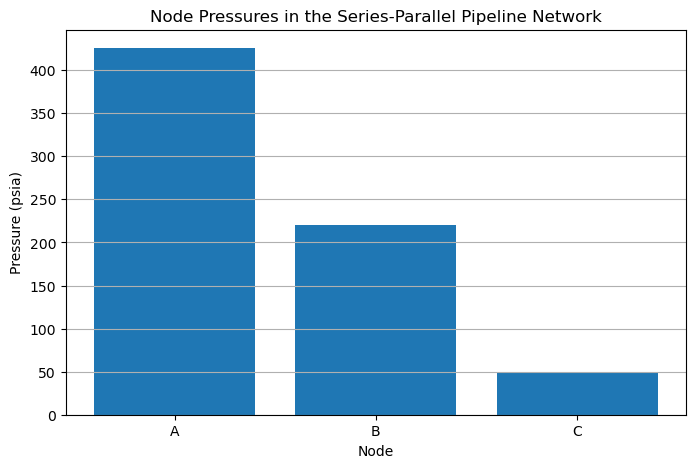

In [47]:
# Bar chart of node pressures

plt.figure(figsize=(8, 5))
plt.bar(node_pressure_df["Node"], node_pressure_df["Pressure (psia)"])
plt.xlabel("Node")
plt.ylabel("Pressure (psia)")
plt.title("Node Pressures in the Series-Parallel Pipeline Network")
plt.grid(axis="y")
plt.show()

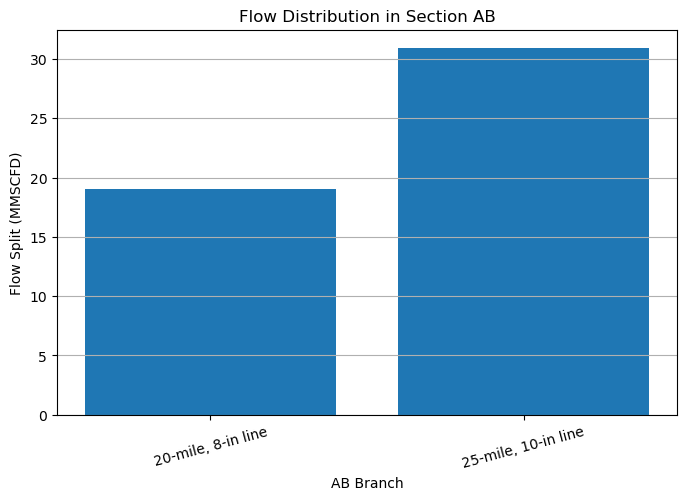

In [48]:
# Bar chart of AB branch flow split

plt.figure(figsize=(8, 5))
plt.bar(AB_flow_split_df["Branch"], AB_flow_split_df["Flow Split (MMSCFD)"])
plt.xlabel("AB Branch")
plt.ylabel("Flow Split (MMSCFD)")
plt.title("Flow Distribution in Section AB")
plt.xticks(rotation=15)
plt.grid(axis="y")
plt.show()

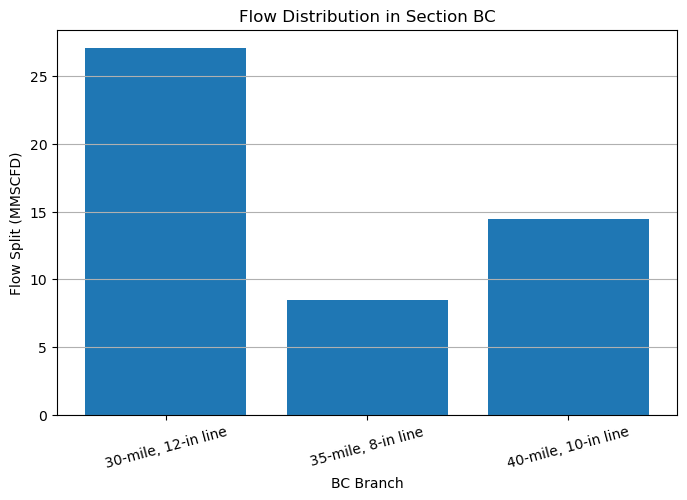

In [49]:
# Bar chart of BC branch flow split

plt.figure(figsize=(8, 5))
plt.bar(BC_flow_split_df["Branch"], BC_flow_split_df["Flow Split (MMSCFD)"])
plt.xlabel("BC Branch")
plt.ylabel("Flow Split (MMSCFD)")
plt.title("Flow Distribution in Section BC")
plt.xticks(rotation=15)
plt.grid(axis="y")
plt.show()

This implementation demonstrates how classical gas pipeline equations can be translated into a computational framework for engineering analysis and design.

#### Part 6: Panhandle B Implementation and Comparison

The Panhandle B equation is implemented in this section for comparison with the Weymouth equation.

Panhandle B is widely used for high-pressure natural gas transmission lines and is generally applied under steady-state, isothermal conditions. In this project, the simplified horizontal-pipeline form is used (no elevation effects).

##### Panhandle B Equation

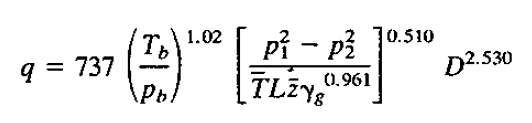
For a horizontal pipeline, the Panhandle B equation in U.S. customary units can be written as:

Q = 737 E (T_b / P_b)^1.02 D^2.53 [ (P_1^2 - P_2^2) / (G^0.961 T L Z) ]^0.51

where:

- Q = gas flow rate (SCFD)
- E = pipeline efficiency
- T_b = base temperature (°R)
- P_b = base pressure (psia)
- D = pipe diameter (inches)
- P_1, P_2 = inlet and outlet pressures (psia)
- G = gas specific gravity
- T = flowing gas temperature (°R)
- L = pipeline length (miles)
- Z = gas compressibility factor

In [50]:
# Define Panhandle B outlet pressure function
def panhandle_b_outlet_pressure(
    flow_value,
    P1,
    D,
    L,
    G,
    T_f,
    Z,
    flow_unit="MMSCFD",
    E=0.95,
    Tb_f=60.0,
    Pb=14.7
):
    """
    Calculate outlet pressure P2 using the horizontal Panhandle B equation.

    Parameters
    ----------
    flow_value : float
        Gas flow rate value.
    P1 : float
        Inlet pressure in psia.
    D : float
        Pipe diameter in inches.
    L : float
        Pipe length in miles.
    G : float
        Gas specific gravity.
    T_f : float
        Flowing gas temperature in °F.
    Z : float
        Compressibility factor.
    flow_unit : str, optional
        Flow-rate unit: 'SCFH', 'SCFD', or 'MMSCFD'. Default is 'MMSCFD'.
    E : float, optional
        Pipeline efficiency factor. Default is 0.95.
    Tb_f : float, optional
        Base temperature in °F. Default is 60°F.
    Pb : float, optional
        Base pressure in psia. Default is 14.7 psia.

    Returns
    -------
    float
        Outlet pressure in psia.
    """
    validate_positive(P1, "Inlet pressure P1")
    validate_positive(D, "Diameter D")
    validate_positive(L, "Length L")
    validate_positive(G, "Gas specific gravity G")
    validate_positive(Z, "Compressibility factor Z")
    validate_positive(E, "Pipeline efficiency E")
    validate_positive(Pb, "Base pressure Pb")

    # Convert flow to SCFD for Panhandle B
    Q = flow_to_scfd(flow_value, flow_unit)

    # Convert temperatures to Rankine
    T = fahrenheit_to_rankine(T_f)
    Tb = fahrenheit_to_rankine(Tb_f)

    # Rearranged Panhandle B equation
    coefficient = 737 * E * ((Tb / Pb) ** 1.02) * (D ** 2.53)

    bracket_term = (Q / coefficient) ** (1 / 0.51)

    delta_p_squared_term = bracket_term * (G ** 0.961) * T * L * Z

    P2_squared = P1**2 - delta_p_squared_term

    if P2_squared <= 0:
        raise ValueError(
            "Calculated P2^2 is zero or negative. "
            "The selected flow may be too high for the given pipeline conditions."
        )

    return np.sqrt(P2_squared)

In [51]:
# Define Panhandle B pressure drop function
def panhandle_b_pressure_drop(
    flow_value,
    P1,
    D,
    L,
    G,
    T_f,
    Z,
    flow_unit="MMSCFD",
    E=0.95,
    Tb_f=60.0,
    Pb=14.7
):
    """
    Calculate outlet pressure and pressure drop using the horizontal Panhandle B equation.

    Returns
    -------
    tuple
        P2 : outlet pressure in psia
        delta_P : pressure drop in psi
    """
    P2 = panhandle_b_outlet_pressure(
        flow_value=flow_value,
        P1=P1,
        D=D,
        L=L,
        G=G,
        T_f=T_f,
        Z=Z,
        flow_unit=flow_unit,
        E=E,
        Tb_f=Tb_f,
        Pb=Pb
    )

    delta_P = P1 - P2
    return P2, delta_P

##### Base-case Panhandle B test using single-pipeline

In [52]:
# Base-case test for Panhandle B
flow_test_pb = 50.0        # MMSCFD
P1_test_pb = 1000.0        # psia
D_test_pb = 12.0           # inches
L_test_pb = 20.0           # miles
G_test_pb = 0.60
T_f_test_pb = 60.0         # °F
Z_test_pb = 0.90
E_test_pb = 0.95

P2_pb, dP_pb = panhandle_b_pressure_drop(
    flow_value=flow_test_pb,
    P1=P1_test_pb,
    D=D_test_pb,
    L=L_test_pb,
    G=G_test_pb,
    T_f=T_f_test_pb,
    Z=Z_test_pb,
    flow_unit="MMSCFD",
    E=E_test_pb
)

print(f"Outlet pressure, P2 = {P2_pb:.6f} psia")
print(f"Pressure drop, ΔP = {dP_pb:.6f} psi")

Outlet pressure, P2 = 966.057874 psia
Pressure drop, ΔP = 33.942126 psi


In [53]:
# PanHandle B results table
panhandle_b_result_df = pd.DataFrame({
    "Parameter": [
        "Flow rate",
        "Flow-rate unit",
        "Inlet pressure",
        "Outlet pressure",
        "Pressure drop",
        "Diameter",
        "Length",
        "Gas specific gravity",
        "Temperature",
        "Compressibility factor",
        "Pipeline efficiency"
    ],
    "Value": [
        flow_test_pb,
        "MMSCFD",
        P1_test_pb,
        P2_pb,
        dP_pb,
        D_test_pb,
        L_test_pb,
        G_test_pb,
        T_f_test_pb,
        Z_test_pb,
        E_test_pb
    ],
    "Unit": [
        "-",
        "-",
        "psia",
        "psia",
        "psi",
        "inches",
        "miles",
        "-",
        "°F",
        "-",
        "-"
    ]
})

panhandle_b_result_df

,Parameter,Value,Unit
0,Flow rate,50.0,-
1,Flow-rate unit,MMSCFD,-
2,Inlet pressure,1000.0,psia
3,Outlet pressure,966.057874,psia
4,Pressure drop,33.942126,psi
5,Diameter,12.0,inches
6,Length,20.0,miles
7,Gas specific gravity,0.6,-
8,Temperature,60.0,°F
9,Compressibility factor,0.9,-


#### Weymouth vs Panhandle B: Base-Case Comparison

In [54]:
# Compare both equations on the same case

# Weymouth result for the same base case
P2_w, dP_w = weymouth_pressure_drop(
    flow_value=flow_test_pb,
    P1=P1_test_pb,
    D=D_test_pb,
    L=L_test_pb,
    G=G_test_pb,
    T_f=T_f_test_pb,
    Z=Z_test_pb,
    flow_unit="MMSCFD"
)

comparison_base_df = pd.DataFrame({
    "Model": ["Weymouth", "Panhandle B"],
    "Outlet Pressure (psia)": [P2_w, P2_pb],
    "Pressure Drop (psi)": [dP_w, dP_pb]
})

comparison_base_df

,Model,Outlet Pressure (psia),Pressure Drop (psi)
0,Weymouth,946.144185,53.855815
1,Panhandle B,966.057874,33.942126


**Interpretation:**  

The base-case comparison shows the difference in pressure-drop prediction between the Weymouth and Panhandle B equations. A lower predicted outlet pressure corresponds to a higher predicted pressure drop. In many transmission-line applications, Weymouth tends to be more conservative than Panhandle B.

In [55]:
# Sensitivity to flow rate using Panhandle B
flow_rates_pb = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])

flow_results_pb = []

for q in flow_rates_pb:
    P2, dP = panhandle_b_pressure_drop(
        flow_value=q,
        P1=1000.0,
        D=12.0,
        L=20.0,
        G=0.60,
        T_f=60.0,
        Z=0.90,
        flow_unit="MMSCFD",
        E=0.95
    )

    flow_results_pb.append({
        "Flow Rate (MMSCFD)": q,
        "Outlet Pressure, P2 (psia)": P2,
        "Pressure Drop, ΔP (psi)": dP
    })

flow_pb_df = pd.DataFrame(flow_results_pb)
flow_pb_df

,Flow Rate (MMSCFD),"Outlet Pressure, P2 (psia)","Pressure Drop, ΔP (psi)"
0,10,998.577393,1.422607
1,20,994.450709,5.549291
2,30,987.669131,12.330869
3,40,978.220850,21.779150
4,50,966.057874,33.942126
5,60,951.099504,48.900496
6,70,933.230638,66.769362
7,80,912.296830,87.703170
8,90,888.096006,111.903994
9,100,860.365771,139.634229


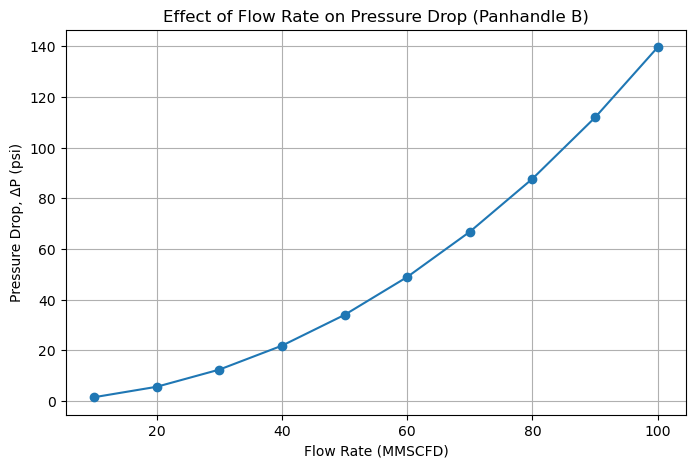

In [56]:
# Plot PanHandle B flow rate sensitivity
plt.figure(figsize=(8, 5))
plt.plot(flow_pb_df["Flow Rate (MMSCFD)"], flow_pb_df["Pressure Drop, ΔP (psi)"], marker='o')
plt.xlabel("Flow Rate (MMSCFD)")
plt.ylabel("Pressure Drop, ΔP (psi)")
plt.title("Effect of Flow Rate on Pressure Drop (Panhandle B)")
plt.grid(True)
plt.show()

In [57]:
# Sensitivity to diameter using Panhandle B
diameters_pb = np.array([8, 10, 12, 14, 16, 18, 20])

diameter_results_pb = []

for d in diameters_pb:
    P2, dP = panhandle_b_pressure_drop(
        flow_value=50.0,
        P1=1000.0,
        D=d,
        L=20.0,
        G=0.60,
        T_f=60.0,
        Z=0.90,
        flow_unit="MMSCFD",
        E=0.95
    )

    diameter_results_pb.append({
        "Diameter (inches)": d,
        "Outlet Pressure, P2 (psia)": P2,
        "Pressure Drop, ΔP (psi)": dP
    })

diameter_pb_df = pd.DataFrame(diameter_results_pb)
diameter_pb_df

,Diameter (inches),"Outlet Pressure, P2 (psia)","Pressure Drop, ΔP (psi)"
0,8,707.987531,292.012469
1,10,913.855558,86.144442
2,12,966.057874,33.942126
3,14,984.346580,15.653420
4,16,991.959915,8.040085
5,18,995.525678,4.474322
6,20,997.349441,2.650559


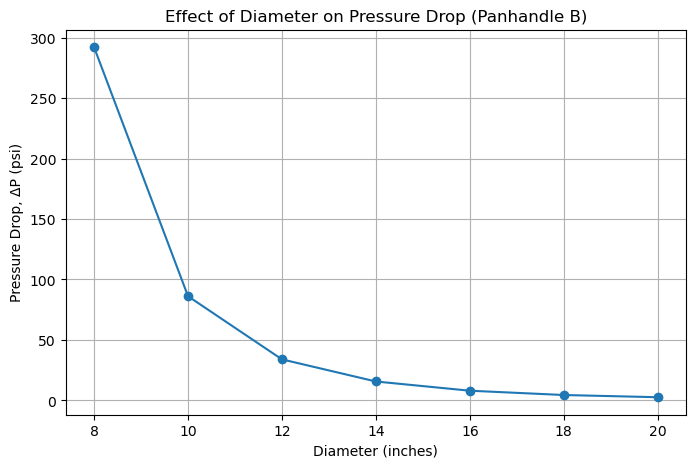

In [58]:
# Plot Panhandle B diameter sensitivity
plt.figure(figsize=(8, 5))
plt.plot(diameter_pb_df["Diameter (inches)"], diameter_pb_df["Pressure Drop, ΔP (psi)"], marker='o')
plt.xlabel("Diameter (inches)")
plt.ylabel("Pressure Drop, ΔP (psi)")
plt.title("Effect of Diameter on Pressure Drop (Panhandle B)")
plt.grid(True)
plt.show()

In [59]:
# Compare Weymouth and Panhandle B over flow rate
comparison_flow_results = []

for q in flow_rates_pb:
    _, dP_w = weymouth_pressure_drop(
        flow_value=q,
        P1=1000.0,
        D=12.0,
        L=20.0,
        G=0.60,
        T_f=60.0,
        Z=0.90,
        flow_unit="MMSCFD"
    )

    _, dP_pb = panhandle_b_pressure_drop(
        flow_value=q,
        P1=1000.0,
        D=12.0,
        L=20.0,
        G=0.60,
        T_f=60.0,
        Z=0.90,
        flow_unit="MMSCFD",
        E=0.95
    )

    comparison_flow_results.append({
        "Flow Rate (MMSCFD)": q,
        "Weymouth Pressure Drop (psi)": dP_w,
        "Panhandle B Pressure Drop (psi)": dP_pb
    })

comparison_flow_df = pd.DataFrame(comparison_flow_results)
comparison_flow_df

,Flow Rate (MMSCFD),Weymouth Pressure Drop (psi),Panhandle B Pressure Drop (psi)
0,10,2.098425,1.422607
1,20,8.420346,5.549291
2,30,19.047415,12.330869
3,40,34.121724,21.779150
4,50,53.855815,33.942126
5,60,78.549026,48.900496
6,70,108.613393,66.769362
7,80,144.615072,87.703170
8,90,187.342772,111.903994
9,100,237.926990,139.634229


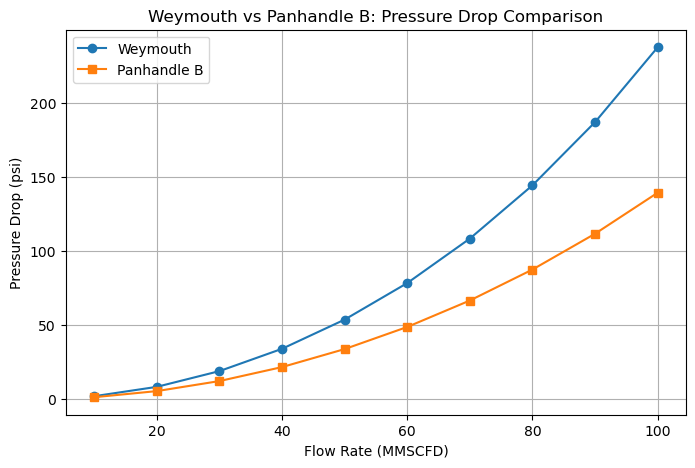

In [60]:
# Plot Weymouth vs Panhandle B comparison
plt.figure(figsize=(8, 5))
plt.plot(
    comparison_flow_df["Flow Rate (MMSCFD)"],
    comparison_flow_df["Weymouth Pressure Drop (psi)"],
    marker='o',
    label="Weymouth"
)
plt.plot(
    comparison_flow_df["Flow Rate (MMSCFD)"],
    comparison_flow_df["Panhandle B Pressure Drop (psi)"],
    marker='s',
    label="Panhandle B"
)
plt.xlabel("Flow Rate (MMSCFD)")
plt.ylabel("Pressure Drop (psi)")
plt.title("Weymouth vs Panhandle B: Pressure Drop Comparison")
plt.grid(True)
plt.legend()
plt.show()

### Engineering Interpretation

The comparison between Weymouth and Panhandle B highlights how different empirical gas-flow correlations can produce different pressure-drop estimates under the same operating conditions.

Key observations include:

- both models predict increasing pressure drop with increasing flow rate,
- both models predict lower pressure drop as diameter increases,
- the magnitude of prediction differs because the equations were developed for different practical operating ranges.

This comparison strengthens the computational framework by showing that the tool is not limited to a single empirical model.

#### Comparative Insight: Weymouth vs Panhandle B

The comparison between Weymouth and Panhandle B reveals systematic differences in predicted pressure drop.

Key observations:

- Weymouth generally predicts a higher pressure drop than Panhandle B under the same conditions.
- This indicates that Weymouth is more conservative, making it suitable for preliminary design and safety-oriented calculations.
- Panhandle B tends to predict lower pressure losses, particularly for high-pressure, large-diameter transmission pipelines.

These differences arise from the empirical basis of the equations and their intended operating ranges.

From an engineering perspective, selecting the appropriate correlation depends on:
- pipeline diameter,
- operating pressure,
- flow regime,
- and required level of conservatism.

#### Limitations of the Model

The present analysis is based on several simplifying assumptions:

- Steady-state, isothermal flow conditions
- Constant gas properties along the pipeline
- Neglect of elevation effects and fittings
- Use of a constant compressibility factor

In real pipeline systems, variations in temperature, pressure, and gas composition may require iterative or equation-of-state-based approaches.

These limitations should be considered when applying the results to real-world systems.

### Conclusion

This project developed a Python-based framework for analyzing pressure drop in natural gas pipelines using both Weymouth and Panhandle B correlations.

The study demonstrated:

- the impact of key parameters such as flow rate, diameter, and pipeline length,
- the modeling of series and parallel pipeline networks,
- and the differences between commonly used empirical flow equations.

The results show that computational tools can effectively translate classical gas-flow equations into practical engineering analysis, enabling both system-level evaluation and detailed flow interpretation.

This framework can be extended to include real-gas behavior, optimization, and digital pipeline monitoring applications.